# DEMO: PIPELINE QUESTION ANSWERING (RETRIEVER & READER)
**Đề tài:** Tìm hiểu về model Sentence-BERT và liên hệ đến bài toán Question & Answering.  

---
Notebook này chia làm 2 phần độc lập:
- **PHẦN I: TIẾNG VIỆT** (Crawl dữ liệu Sổ tay sinh viên Phenikaa và đánh giá bằng mô hình đa ngôn ngữ).
- **PHẦN II: TIẾNG ANH** (Tải dữ liệu SQuAD 2.0 từ Hugging Face và đánh giá bằng mô hình tiếng Anh).

### Công nghệ sử dụng:
- **Retriever:** Sentence-BERT + **ChromaDB (Vector Database)**.
- **Reader:** Transformers Pipeline QA (`xlm-roberta` cho tiếng Việt và `roberta` cho tiếng Anh).
- **Lưu trữ dữ liệu:** Toàn bộ dữ liệu cào và cơ sở dữ liệu ChromaDB được tự động lưu trữ trên **Google Drive**.

## Cài đặt môi trường



In [1]:
!pip install -q sentence-transformers
!pip install -q transformers==4.44.2
!pip install -q tabulate datasets accelerate beautifulsoup4 requests chromadb "opentelemetry-api<1.42.1" "opentelemetry-sdk<1.42.1"

In [2]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
from transformers import pipeline
import chromadb
from tabulate import tabulate
from IPython.display import display, HTML
import requests
from bs4 import BeautifulSoup
import concurrent.futures
from datasets import load_dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/NLP_BTL_Data"
os.makedirs(DATA_DIR, exist_ok=True)
print(f"Thư mục lưu trữ DB trên Google Drive: {DATA_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Thư mục lưu trữ DB trên Google Drive: /content/drive/MyDrive/NLP_BTL_Data


# PHẦN I: PIPELINE TIẾNG VIỆT (CRAWL DATA TỪ SỔ TAY PHENIKAA)

### 1. Hàm cào dữ liệu từ Sổ tay sinh viên Phenikaa University

In [33]:
import re
import html

def clean_markdown(text):
    text = html.unescape(text)
    text = re.sub(r'{%.*?%}', '', text)   # Xóa bỏ các cú pháp GitBook {% ... %}
    lines = [line.strip() for line in text.split('\n')]
    cleaned_lines = []
    for line in lines:
        if line.startswith("> For the complete") or "llms.txt" in line:
            continue
        cleaned_lines.append(line)

    text = '\n'.join(cleaned_lines)
    text = re.sub(r'\n\s*\n+', '\n\n', text).strip()
    return text

def crawl_phenikaa_handbook():
    index_url = "https://sotaysv.phenikaa-uni.edu.vn/home/~gitbook/site-index"
    resp = requests.get(index_url)
    if resp.status_code != 200:
        raise Exception(f"Không thể lấy được chỉ mục trang web. Mã lỗi: {resp.status_code}")

    data = resp.json()
    pages = sorted(data['pages'], key=lambda x: x['pathname'])

    print(f"Tìm thấy {len(pages)} trang.")

    def fetch_page_markdown(page):
        path = page['pathname']
        if path == "/home" or path == "/":
            return None, None
        md_url = f"https://sotaysv.phenikaa-uni.edu.vn{path}.md"
        try:
            r = requests.get(md_url, timeout=10)
            if r.status_code == 200:
                raw_text = r.text
                cleaned_text = clean_markdown(raw_text)
                if len(cleaned_text) > 50:
                    return path, cleaned_text
        except:
            pass
        return None, None

    with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
        results = list(executor.map(fetch_page_markdown, pages))

    crawled_data = [(path, text) for path, text in results if path is not None]
    crawled_data.sort(key=lambda x: x[0])

    unique_contexts = [item[1] for item in crawled_data]
    path_to_id = {item[0]: idx for idx, item in enumerate(crawled_data)}

    raw_queries = [
        {
            "question": "GPA đạt dưới bao nhiêu sau học kỳ đầu tiên thì sinh viên bị cảnh cáo học vụ?",
            "path": "/home/1.-hoat-dong-dao-tao-tai-truong-dai-hoc-phenikaa/1.10-canh-bao-ket-qua-hoc-tap-buoc-thoi-hoc",
            "answer": "dưới 1.20"
        },
        {
            "question": "Sinh viên bị cảnh cáo học vụ mấy lần liên tiếp thì bị buộc thôi học?",
            "path": "/home/1.-hoat-dong-dao-tao-tai-truong-dai-hoc-phenikaa/1.10-canh-bao-ket-qua-hoc-tap-buoc-thoi-hoc",
            "answer": "2 lần liên tiếp"
        },
        {
            "question": "Sinh viên được xin rút bớt học phần trong khoảng thời gian nào kể từ khi bắt đầu học kỳ chính?",
            "path": "/home/1.-hoat-dong-dao-tao-tai-truong-dai-hoc-phenikaa/1.5-dang-ky-khoi-luong-hoc-tap-va-rut-bot-hoc-phan-da-dang-ky",
            "answer": "6 tuần"
        },
        {
            "question": "Thời gian nghỉ học tạm thời tối đa cho sinh viên đối với mỗi lần xin phép là bao lâu?",
            "path": "/home/1.-hoat-dong-dao-tao-tai-truong-dai-hoc-phenikaa/1.7-nghi-hoc-tam-thoi",
            "answer": "không quá 2 học kỳ chính"
        },
        {
            "question": "Lệ phí phúc khảo cho mỗi bài thi kết thúc học phần cần nộp là bao nhiêu tiền?",
            "path": "/home/1.-hoat-dong-dao-tao-tai-truong-dai-hoc-phenikaa/1.13-khieu-nai-diem-va-xem-lai-ket-qua-bai-thi-hoc-phan",
            "answer": "30.000 đồng"
        },
        {
            "question": "Chứng chỉ tiếng Anh quốc tế tối thiểu đạt bao nhiêu điểm IELTS để xét tốt nghiệp?",
            "path": "/home/1.-hoat-dong-dao-tao-tai-truong-dai-hoc-phenikaa/1.15-dieu-kien-xet-tot-nghiep-va-cong-nhan-tot-nghiep",
            "answer": "5.0"
        },
        {
            "question": "Bảo hiểm y tế học sinh sinh viên là hình thức bảo hiểm như thế nào?",
            "path": "/home/8.-bao-hiem-y-te",
            "answer": "bắt buộc"
        },
        {
            "question": "Thẻ sinh viên tích hợp những dịch vụ gì trong trường?",
            "path": "/home/2.-hoat-dong-cong-tac-sinh-vien/2.1-ho-tro-hanh-chinh-1-cua-quan-ly-thong-tin-sinh-vien",
            "answer": "thẻ thư viện, thẻ gửi xe"
        },
        {
            "question": "Sinh viên nghiên cứu khoa học đạt giải nhất cấp Trường được thưởng bao nhiêu tiền?",
            "path": "/home/9.-nghien-cuu-khoa-hoc-sinh-vien",
            "answer": "2.000.000 đồng"
        },
        {
            "question": "Sinh viên muốn mượn sách thư viện về nhà phải xuất trình giấy tờ gì?",
            "path": "/home/4.-trung-tam-thong-tin-thu-vien",
            "answer": "thẻ sinh viên"
        },
        {
            "question": "Mức đóng bảo hiểm y tế của học sinh sinh viên bằng bao nhiêu phần trăm mức lương cơ sở?",
            "path": "/home/8.-bao-hiem-y-te/8.3.-muc-dong-ho-tro-dong-theo-quy-dinh",
            "answer": "4,5%"
        },
        {
            "question": "Thủ tục xin cấp lại thẻ bảo hiểm y tế bị mất được giải quyết ở đâu?",
            "path": "/home/8.-bao-hiem-y-te/8.6-thu-tuc-cap-lai-the-mat-hoac-thay-doi-thong-tin-tren-the",
            "answer": "cơ quan BHXH"
        },
        {
            "question": "Để khôi phục mật khẩu tài khoản Portal, sinh viên có thể tự thực hiện bằng cách nào?",
            "path": "/home/10.-he-thong-cong-nghe-thong-tin/10.3-ho-tro-x-ly-su-co-cntt",
            "answer": "số điện thoại"
        },
        {
            "question": "Tỷ lệ trùng lặp tối đa được Turnitin cho phép đối với báo cáo thực tập tốt nghiệp là bao nhiêu phần trăm?",
            "path": "/home/1.-hoat-dong-dao-tao-tai-truong-dai-hoc-phenikaa/1.15-dieu-kien-xet-tot-nghiep-va-cong-nhan-tot-nghiep",
            "answer": "dưới 20%"
        },
        {
            "question": "Chi phí ở ký túc xá cho phòng tiêu chuẩn 8 người tại trường là bao nhiêu một tháng?",
            "path": "/home/7.-ky-tuc-xa-sinh-vien",
            "answer": "250.000 đồng/tháng"
        },
        {
            "question": "Thời gian phục vụ mượn sách và đọc sách tại thư viện mở cửa vào các giờ nào?",
            "path": "/home/4.-trung-tam-thong-tin-thu-vien",
            "answer": "từ 8h00 đến 21h00"
        },
        {
            "question": "Các mức xét học bổng khuyến khích học tập bao gồm những mức nào?",
            "path": "/home/2.-hoat-dong-cong-tac-sinh-vien/2.3-hoc-bong-khuyen-khich-hoc-tap-ren-luyen-khen-thuong-ky-luat-sinh-vien",
            "answer": "Khá, Giỏi, Xuất sắc"
        },
        {
            "question": "Hình phạt đối với hành vi mang điện thoại hoặc tài liệu vào phòng thi kết thúc học phần là gì?",
            "path": "/home/1.-hoat-dong-dao-tao-tai-truong-dai-hoc-phenikaa/1.12-dieu-kien-du-thi-to-chuc-thi-ket-thuc-hoc-phan",
            "answer": "đình chỉ thi"
        },
        {
            "question": "Sinh viên muốn mượn sách thư viện về nhà phải xuất trình giấy tờ gì?",
            "path": "/home/4.-trung-tam-thong-tin-thu-vien",
            "answer": "thẻ sinh viên"
        },
        {
            "question": "Sinh viên hệ chính quy được đăng ký tối thiểu bao nhiêu tín chỉ trong một học kỳ chính?",
            "path": "/home/1.-hoat-dong-dao-tao-tai-truong-dai-hoc-phenikaa/1.5-dang-ky-khoi-luong-hoc-tap-va-rut-bot-hoc-phan-da-dang-ky",
            "answer": "12 tín chỉ"
        },
        {
            "question": "Lệ phí làm lại thẻ sinh viên khi bị mất hoặc hỏng là bao nhiêu?",
            "path": "/home/2.-hoat-dong-cong-tac-sinh-vien/2.1-ho-tro-hanh-chinh-1-cua-quan-ly-thong-tin-sinh-vien",
            "answer": "50.000 VNĐ"
        }
    ]

    queries = []
    for q in raw_queries:
        path = q['path']
        if path in path_to_id:
            queries.append({
                "question": q['question'],
                "ground_truth": path_to_id[path],
                "answer": q['answer']
            })
    return unique_contexts, queries

### 2. Thiết lập ChromaDB và Nạp/Mã hóa văn bản Tiếng Việt

In [34]:
sbert_model_vi = SentenceTransformer('sentence-transformers/paraphrase-multilingual-mpnet-base-v2')

chroma_dir_vi = os.path.join(DATA_DIR, "chroma_db_vi")
chroma_client_vi = chromadb.PersistentClient(path=chroma_dir_vi)
collection_name_vi = "phenikaa_collection"

existing_collections = [c.name for c in chroma_client_vi.list_collections()]
crawled_vi = True

if collection_name_vi in existing_collections:
    collection_vi = chroma_client_vi.get_collection(name=collection_name_vi)
    if collection_vi.count() > 0:
        queries_json_path = os.path.join(DATA_DIR, "queries_vi.json")
        if os.path.exists(queries_json_path):
            with open(queries_json_path, "r", encoding="utf-8") as f:
                queries_vi = json.load(f)
            db_data = collection_vi.get()
            sorted_indices = np.argsort([int(x) for x in db_data['ids']])
            contexts_vi = [db_data['documents'][i] for i in sorted_indices]
            crawled_vi = False

if crawled_vi:
    contexts_vi, queries_vi = crawl_phenikaa_handbook()
    context_embeddings_vi = sbert_model_vi.encode(contexts_vi)
    print("Đã mã hóa văn bản tiếng Việt sang Vector Embeddings.")

    # Lưu vào ChromaDB trên Google Drive
    if collection_name_vi in existing_collections:
        chroma_client_vi.delete_collection(name=collection_name_vi)

    collection_vi = chroma_client_vi.create_collection(
        name=collection_name_vi,
        metadata={"hnsw:space": "cosine"}
    )

    collection_vi.add(
        embeddings=context_embeddings_vi.tolist(),
        documents=contexts_vi,
        ids=[str(i) for i in range(len(contexts_vi))]
    )

    # Lưu queries
    queries_json_path = os.path.join(DATA_DIR, "queries_vi.json")
    with open(queries_json_path, "w", encoding="utf-8") as f:
        json.dump(queries_vi, f, ensure_ascii=False, indent=2)

print(f"Tổng số văn bản trong DB tiếng Việt: {len(contexts_vi)}")

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Tổng số văn bản trong DB tiếng Việt: 88


Xem thử mẫu dữ liệu đã cào

In [6]:
print(f"Tổng số trang đã cào thành công: {len(contexts_vi)}")
for idx, context in enumerate(contexts_vi[:3]):
    print(f"\n[Trang {idx+1}]")
    lines = context.split('\n')
    title = lines[0] if lines else "Không có tiêu đề"
    print(f"Tiêu đề/Dòng đầu: {title}")
    print(f"Nội dung mẫu: {context[:2000]}...")
    print("-" * 50)

Tổng số trang đã cào thành công: 88

[Trang 1]
Tiêu đề/Dòng đầu: # 1. CÁC NGÀNH ĐÀO TẠO / CHƯƠNG TRÌNH ĐÀO TẠO CỦA TRƯỜNG
Nội dung mẫu: # 1. CÁC NGÀNH ĐÀO TẠO / CHƯƠNG TRÌNH ĐÀO TẠO CỦA TRƯỜNG

[1. KHỐI NGÀNH KĨ THUẬT VÀ CÔNG NGHỆ](/home/1.-cac-nganh-dao-tao-chuong-trinh-dao-tao-cua-truong/1.-khoi-nganh-ki-thuat-va-cong-nghe.md)

[2. KHỐI NGÀNH KINH TẾ - KINH DOANH](/home/1.-cac-nganh-dao-tao-chuong-trinh-dao-tao-cua-truong/2.-khoi-nganh-kinh-te-kinh-doanh.md)

[3. KHỐI NGÀNH KHOA HỌC SỨC KHỎE](/home/1.-cac-nganh-dao-tao-chuong-trinh-dao-tao-cua-truong/3.-khoi-nganh-khoa-hoc-suc-kh-e.md)

[4. NHÓM NGÀNH KHOA HỌC XÃ HỘI VÀ NHÂN VĂN](/home/1.-cac-nganh-dao-tao-chuong-trinh-dao-tao-cua-truong/4.-nhom-nganh-khoa-hoc-xa-hoi-va-nhan-van.md)

[5. CHƯƠNG TRÌNH ĐÀO TẠO QUỐC TẾ](/home/1.-cac-nganh-dao-tao-chuong-trinh-dao-tao-cua-truong/5.-chuong-trinh-dao-tao-quoc-te.md)...
--------------------------------------------------

[Trang 2]
Tiêu đề/Dòng đầu: # 1. KHỐI NGÀNH KĨ THUẬT VÀ CÔNG NGHỆ
Nội 

### 3. Online Retrieval & Reader (Tiếng Việt)

In [50]:
def retrieve_top_k_vi(query_string, k=3):
    query_vector = sbert_model_vi.encode([query_string])
    start_t = time.time()
    results = collection_vi.query(
        query_embeddings=query_vector.tolist(),
        n_results=k
    )
    search_time_ms = (time.time() - start_t) * 1000

    formatted_results = []
    ids = results['ids'][0]
    documents = results['documents'][0]
    distances = results['distances'][0] if 'distances' in results and results['distances'] else [1.0]*k

    for i in range(len(ids)):
        formatted_results.append({
            "id": int(ids[i]),
            "context": documents[i],
            "score": 1.0 - float(distances[i])
        })
    return formatted_results, search_time_ms


# Reader: Extractive QA
reader_pipeline_vi = pipeline("question-answering", model="ancs21/xlm-roberta-large-vi-qa")

def extract_answer_vi(question_string, context_string):
    result = reader_pipeline_vi(question=question_string, context=context_string)
    return result

def run_demo_vi(question):
    k = 5
    retrieved_docs, retrieve_time = retrieve_top_k_vi(question, k=k)
    top_1_doc = retrieved_docs[0]
    reader_res = extract_answer_vi(question, top_1_doc['context'])

    print(f"Câu hỏi: {question}")
    print(f"Thời gian tìm kiếm (ChromaDB): {retrieve_time:.2f} ms")
    print(f"Đáp án: '{reader_res['answer'].strip()}'")
    print(f"Confidence: {reader_res['score']:.4f}")
    print(f"\n\nTop {k} văn bản được Retriever tìm thấy:")
    for i, doc in enumerate(retrieved_docs):
        print(f"\n[Top {i+1}] ID={doc['id']} | Score={doc['score']:.4f}")
        print(doc['context'][:300] + "..." if len(doc['context']) > 300 else doc['context'])
        print("-" * 50)

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


### 4. Chạy Demo Tiếng Việt

In [51]:
run_demo_vi("GPA tích lũy dưới bao nhiêu thì bị cảnh cáo học vụ sau kỳ đầu tiên của khóa học?")

Câu hỏi: GPA tích lũy dưới bao nhiêu thì bị cảnh cáo học vụ sau kỳ đầu tiên của khóa học?
Thời gian tìm kiếm (ChromaDB): 10.25 ms
Đáp án: '0,8'
Confidence: 0.8248


Top 5 văn bản được Retriever tìm thấy:

[Top 1] ID=9 | Score=0.7868
# 1.10 Cảnh báo kết quả học tập, buộc thôi học

**1.10.1. Cuối mỗi học kỳ, sinh viên bị cảnh báo học tập nếu rơi vào một trong các trường hợp sau:**

a) Điểm trung bình học kỳ đạt dưới 0,8 đối với học kỳ đầu của khóa học, dưới 1,0 đối với các học kỳ tiếp theo;

b)  Điểm trung bình tích lũy đạt dưới ...
--------------------------------------------------

[Top 2] ID=15 | Score=0.6621
# 1.16 Cấp bằng tốt nghiệp

**1.16.1. Bằng tốt nghiệp đại học được ghi theo ngành đào tạo và kèm theo phụ lục văn bằng (bảng điểm). Phụ lục văn bằng (bảng điểm) phải ghi rõ ngành và chuyên ngành đào tạo hoặc ngành phụ (nếu có); xếp loại rèn luyện và kết quả học tập cao nhất đã tích lũy theo từng học...
--------------------------------------------------

[Top 3] ID=25 | Score=0.66

In [52]:
run_demo_vi("Thời hạn sử dụng thẻ bảo hiểm xem như thế nào?")

Câu hỏi: Thời hạn sử dụng thẻ bảo hiểm xem như thế nào?
Thời gian tìm kiếm (ChromaDB): 3.58 ms
Đáp án: '15 tháng từ 01/10/2024 đến hết 31/12/2025.'
Confidence: 0.1084


Top 5 văn bản được Retriever tìm thấy:

[Top 1] ID=76 | Score=0.5184
# 8.4 Thời hạn sử dụng

Nhà trường sẽ tổ chức mua theo năm tài chính (01 năm)

• Đối với tân sinh viên có thẻ BHYT hết hạn ngày 31/9/2024 sẽ mua BHYT 15 tháng từ 01/10/2024 đến hết 31/12/2025.

• Đối với sinh viên có thẻ BHYT hết hạn ngày 31/12/2024 sẽ mua BHYT 12 tháng từ 01/01/2025 đến 31/12/2025.
--------------------------------------------------

[Top 2] ID=75 | Score=0.5000
# 8.3. Mức đóng, hỗ trợ đóng theo quy định

• Số tiền đóng = **Mức lương cơ sở** x **4,5%** x **số tháng tham gia** (Tại thời điểm đóng tiền)

Trong đó: **Học sinh - Sinh viên đóng 70%;**

**Ngân sách nhà nước hỗ trợ 30%.**

Thời hạn sử dụng thẻ BHYT tương ứng với số tiền đóng mua BHYT.

Ví dụ:

*1....
--------------------------------------------------

[Top 3] ID=80 | Score=0.

### 4.1. Giải pháp nâng cao 1: Gộp Top-K tài liệu làm ngữ cảnh (Context Concatenation)
Thay vì chỉ ném duy nhất tài liệu Top 1 cho Reader, chúng ta gộp chung nội dung của cả `k` tài liệu tìm được lại làm ngữ cảnh đầu vào lớn. Điều này giúp Reader bao quát được thông tin ngay cả khi Retriever xếp hạng tài liệu chính xác ở vị trí thấp (như hạng 4).

In [30]:
def run_demo_vi_concat(question, k=5):
    # Tìm kiếm top-k tài liệu liên quan
    retrieved_docs, retrieve_time = retrieve_top_k_vi(question, k=k)

    # Gộp toàn bộ văn bản của top k lại
    combined_context = "\n\n".join([doc['context'] for doc in retrieved_docs])

    # Cho Reader đọc hiểu trên ngữ cảnh gộp
    start_reader = time.time()
    reader_res = extract_answer_vi(question, combined_context)
    reader_time_ms = (time.time() - start_reader) * 1000

    print(f"Câu hỏi: {question}")
    print(f"Thời gian tìm kiếm (ChromaDB): {retrieve_time:.2f} ms")
    print(f"Thời gian đọc hiểu (Reader): {reader_time_ms:.2f} ms")
    print(f"Đáp án trích xuất: '{reader_res['answer'].strip()}'")
    print(f"Confidence: {reader_res['score']:.4f}")

run_demo_vi_concat("Thời hạn sử dụng thẻ bảo hiểm xem như thế nào?", k=5)

Câu hỏi: Thời hạn sử dụng thẻ bảo hiểm xem như thế nào?
Thời gian tìm kiếm (ChromaDB): 4.53 ms
Thời gian đọc hiểu (Reader): 19701.07 ms
Đáp án trích xuất: '(Hạn thẻ)'
Confidence: 0.8430


### 4.2. Giải pháp nâng cao 2: Sử dụng Reranker (Cross-Encoder) tái xếp hạng tài liệu
Đây là luồng thiết kế tiêu chuẩn trong các hệ thống RAG thực tế (Multi-stage RAG):
1. **Giai đoạn 1 (Retriever - Bi-Encoder):** Dùng ChromaDB + SBERT để lọc nhanh ra một danh sách ứng viên (ví dụ: Top 10 tài liệu) với tốc độ tìm kiếm cực nhanh (mili-giây).
2. **Giai đoạn 2 (Reranker - Cross-Encoder):** Sử dụng mô hình Cross-Encoder chuyên biệt (`thanhtantran/Vietnamese_Reranker`) để chấm điểm tương tác sâu giữa câu hỏi và từng ứng viên, từ đó đưa tài liệu chính xác nhất lên vị trí Top 1 trước khi đưa vào Reader.

In [35]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

rerank_tokenizer = AutoTokenizer.from_pretrained('thanhtantran/Vietnamese_Reranker')
rerank_model = AutoModelForSequenceClassification.from_pretrained('thanhtantran/Vietnamese_Reranker').to(device)
rerank_model.eval()
print("Đã tải mô hình Reranker (thanhtantran/Vietnamese_Reranker) từ Hugging Face")

def rerank_documents(query, docs):
    pairs = [[query, doc['context']] for doc in docs]
    inputs = rerank_tokenizer(pairs, padding=True, truncation=True, max_length=512, return_tensors='pt').to(device)

    with torch.no_grad():
        outputs = rerank_model(**inputs)
        scores = outputs.logits.view(-1).cpu().tolist()

    # Cập nhật điểm rerank cho từng tài liệu
    for i, doc in enumerate(docs):
        doc['rerank_score'] = scores[i]

    sorted_docs = sorted(docs, key=lambda x: x['rerank_score'], reverse=True)
    return sorted_docs

def run_demo_vi_rerank(question, top_n_retrieve=10):
    # Retriever tìm nhanh Top k ứng viên
    retrieved_docs, retrieve_time = retrieve_top_k_vi(question, k=top_n_retrieve)

    # Dùng Cross-Encoder tái xếp hạng các ứng viên
    start_rerank = time.time()
    reranked_docs = rerank_documents(question, retrieved_docs)
    rerank_time_ms = (time.time() - start_rerank) * 1000

    # Lấy tài liệu Top 1 sau khi Rerank để làm context
    top_1_reranked = reranked_docs[0]
    reader_res = extract_answer_vi(question, top_1_reranked['context'])

    print(f"Câu hỏi: {question}")
    print(f"Thời gian tìm kiếm (ChromaDB Bi-Encoder): {retrieve_time:.2f} ms")
    print(f"Thời gian Rerank (Vietnamese_Reranker): {rerank_time_ms:.2f} ms")
    print(f"Đáp án trích xuất: '{reader_res['answer'].strip()}'")
    print(f"Confidence: {reader_res['score']:.4f}")
    print(f"Tài liệu được chọn sau Rerank: ID={top_1_reranked['id']}")

    print(f"\n\nBảng so sánh 5 hạng đầu trước và sau Rerank")
    for i in range(min(5, len(reranked_docs))):
        orig_rank = retrieved_docs.index(reranked_docs[i]) + 1
        print(f"Rerank hạng {i+1} -> Hạng cũ: {orig_rank} | ID: {reranked_docs[i]['id']} | Score cũ: {reranked_docs[i]['score']:.4f} | Score Rerank: {reranked_docs[i]['rerank_score']:.4f}")

# Chạy thử nghiệm với Reranking
run_demo_vi_rerank("Thời hạn sử dụng thẻ bảo hiểm xem như thế nào?", top_n_retrieve=10)

Đã tải mô hình Reranker (thanhtantran/Vietnamese_Reranker) từ Hugging Face
Câu hỏi: Thời hạn sử dụng thẻ bảo hiểm xem như thế nào?
Thời gian tìm kiếm (ChromaDB Bi-Encoder): 4.01 ms
Thời gian Rerank (Vietnamese_Reranker): 51586.50 ms
Đáp án trích xuất: '(Hạn thẻ)'
Confidence: 0.8383
Tài liệu được chọn sau Rerank: ID=80


Bảng so sánh 5 hạng đầu trước và sau Rerank
Rerank hạng 1 -> Hạng cũ: 3 | ID: 80 | Score cũ: 0.4869 | Score Rerank: -2.7617
Rerank hạng 2 -> Hạng cũ: 2 | ID: 75 | Score cũ: 0.5000 | Score Rerank: -2.8583
Rerank hạng 3 -> Hạng cũ: 1 | ID: 76 | Score cũ: 0.5184 | Score Rerank: -5.1002
Rerank hạng 4 -> Hạng cũ: 6 | ID: 72 | Score cũ: 0.4236 | Score Rerank: -7.8523
Rerank hạng 5 -> Hạng cũ: 5 | ID: 77 | Score cũ: 0.4326 | Score Rerank: -9.2115


### 5. Đánh giá kết quả (Tiếng Việt)

+-----------+---------+-------+
| Metric    |   Score | %     |
+===========+=========+=======+
| Recall@1  |  0.4762 | 47.6% |
+-----------+---------+-------+
| Recall@3  |  0.6667 | 66.7% |
+-----------+---------+-------+
| Recall@5  |  0.8095 | 81.0% |
+-----------+---------+-------+
| Recall@10 |  0.9048 | 90.5% |
+-----------+---------+-------+
| Recall@20 |  0.9524 | 95.2% |
+-----------+---------+-------+
| MRR       |  0.5943 | -     |
+-----------+---------+-------+


,Câu hỏi,Ground Truth ID,Rank,Reciprocal Rank (RR)
STT,,,,
1,GPA đạt dưới bao nhiêu sau học kỳ đầu tiên thì...,9,1,1.0000
2,Sinh viên bị cảnh cáo học vụ mấy lần liên tiếp...,9,1,1.0000
3,Sinh viên được xin rút bớt học phần trong khoả...,21,1,1.0000
4,Thời gian nghỉ học tạm thời tối đa cho sinh vi...,23,1,1.0000
5,Lệ phí phúc khảo cho mỗi bài thi kết thúc học ...,12,4,0.2500
6,Chứng chỉ tiếng Anh quốc tế tối thiểu đạt bao ...,14,1,1.0000
7,Bảo hiểm y tế học sinh sinh viên là hình thức ...,72,13,0.0769
8,Thẻ sinh viên tích hợp những dịch vụ gì trong ...,45,3,0.3333
9,Sinh viên nghiên cứu khoa học đạt giải nhất cấ...,82,1,1.0000


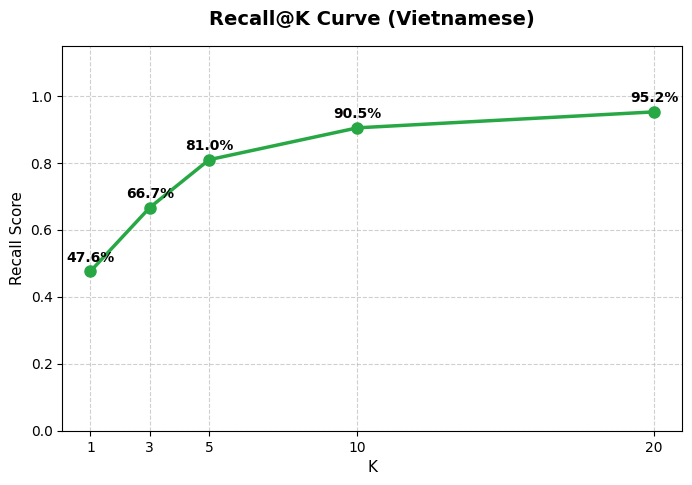

({1: 0.47619047619047616,
  3: 0.6666666666666666,
  5: 0.8095238095238095,
  10: 0.9047619047619048,
  20: 0.9523809523809523},
 np.float64(0.5943281586138729))

In [47]:
def evaluate_retrieval_system_vi():
    k_values = [1, 3, 5, 10, 20]
    recall_hits = {k: 0 for k in k_values}
    reciprocal_ranks = []
    detailed_records = []

    for idx, item in enumerate(queries_vi):
        question = item['question']
        gt_id = item['ground_truth']

        retrieved_docs, _ = retrieve_top_k_vi(question, k=20)
        retrieved_ids = [doc['id'] for doc in retrieved_docs]

        if gt_id in retrieved_ids:
            rank = retrieved_ids.index(gt_id) + 1
            rr = 1.0 / rank
        else:
            rank = -1
            rr = 0.0

        reciprocal_ranks.append(rr)

        for k in k_values:
            if gt_id in retrieved_ids[:k]:
                recall_hits[k] += 1

        detailed_records.append({
            "STT": idx + 1,
            "Câu hỏi": question,
            "Ground Truth ID": gt_id,
            "Rank": rank if rank != -1 else "N/A",
            "Reciprocal Rank (RR)": f"{rr:.4f}"
        })

    total_queries = len(queries_vi)
    recall_scores = {k: recall_hits[k] / total_queries for k in k_values}
    mrr_score = np.mean(reciprocal_ranks)

    summary_table = [
        ["Metric", "Score", "%"],
        ["Recall@1", f"{recall_scores[1]:.4f}", f"{recall_scores[1]*100:.1f}%"],
        ["Recall@3", f"{recall_scores[3]:.4f}", f"{recall_scores[3]*100:.1f}%"],
        ["Recall@5", f"{recall_scores[5]:.4f}", f"{recall_scores[5]*100:.1f}%"],
        ["Recall@10", f"{recall_scores[10]:.4f}", f"{recall_scores[10]*100:.1f}%"],
        ["Recall@20", f"{recall_scores[20]:.4f}", f"{recall_scores[20]*100:.1f}%"],
        ["MRR", f"{mrr_score:.4f}", "-"]
    ]
    print(tabulate(summary_table, headers="firstrow", tablefmt="grid"))

    df_details = pd.DataFrame(detailed_records)
    display(df_details.set_index("STT"))

    plt.figure(figsize=(8, 5))
    y_values = [recall_scores[k] for k in k_values]
    plt.plot(k_values, y_values, marker='o', markersize=8, color='#28a745', linestyle='-', linewidth=2.5)

    for k, val in zip(k_values, y_values):
        plt.text(k, val + 0.02, f"{val*100:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.title("Recall@K Curve (Vietnamese)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("K", fontsize=11)
    plt.ylabel("Recall Score", fontsize=11)
    plt.xticks(k_values)
    plt.ylim(0, 1.15)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    return recall_scores, mrr_score

evaluate_retrieval_system_vi()

# PHẦN II: PIPELINE TIẾNG ANH (DATASET SQuAD 2.0)

### 1. Hàm nạp dữ liệu SQuAD 2.0 từ Hugging Face

In [37]:
def load_english_squad():
    squad = load_dataset("squad_v2", split="validation")
    unique_contexts = []
    queries = []
    context_map = {}

    for item in squad:
        c = item['context']
        q = item['question']
        if not item['answers']['text']:
            continue
        ans = item['answers']['text'][0]

        if c not in context_map:
            if len(context_map) >= 100:
                continue
            context_map[c] = len(unique_contexts)
            unique_contexts.append(c)

        c_id = context_map[c]
        if len(queries) < 30:
            queries.append({
                "question": q,
                "ground_truth": c_id,
                "answer": ans
            })

        if len(unique_contexts) >= 100 and len(queries) >= 30:
            break

    return unique_contexts, queries

### 2. Thiết lập ChromaDB và Nạp/Mã hóa văn bản Tiếng Anh

In [38]:
sbert_model_en = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

chroma_dir_en = os.path.join(DATA_DIR, "chroma_db_en")
chroma_client_en = chromadb.PersistentClient(path=chroma_dir_en)
collection_name_en = "squad_collection"

existing_collections_en = [c.name for c in chroma_client_en.list_collections()]
loaded_en = True

if collection_name_en in existing_collections_en:
    collection_en = chroma_client_en.get_collection(name=collection_name_en)
    if collection_en.count() > 0:
        queries_json_path = os.path.join(DATA_DIR, "queries_en.json")
        if os.path.exists(queries_json_path):
            with open(queries_json_path, "r", encoding="utf-8") as f:
                queries_en = json.load(f)
            db_data = collection_en.get()
            sorted_indices = np.argsort([int(x) for x in db_data['ids']])
            contexts_en = [db_data['documents'][i] for i in sorted_indices]
            print("-> Đã tìm thấy Cơ sở dữ liệu ChromaDB tiếng Anh cũ trên Google Drive! Bỏ qua bước tải Hugging Face và mã hóa.")
            loaded_en = False

if loaded_en:
    # Tải dữ liệu SQuAD
    contexts_en, queries_en = load_english_squad()

    # Mã hóa dữ liệu
    print("Mã hóa văn bản tiếng Anh sang Vector Embeddings...")
    context_embeddings_en = sbert_model_en.encode(contexts_en)

    # Lưu vào ChromaDB trên Google Drive
    if collection_name_en in existing_collections_en:
        chroma_client_en.delete_collection(name=collection_name_en)

    collection_en = chroma_client_en.create_collection(
        name=collection_name_en,
        metadata={"hnsw:space": "cosine"}
    )

    collection_en.add(
        embeddings=context_embeddings_en.tolist(),
        documents=contexts_en,
        ids=[str(i) for i in range(len(contexts_en))]
    )

    # Lưu queries để phục vụ đánh giá sau này
    queries_json_path = os.path.join(DATA_DIR, "queries_en.json")
    with open(queries_json_path, "w", encoding="utf-8") as f:
        json.dump(queries_en, f, ensure_ascii=False, indent=2)
    print("-> Đã tải mới, mã hóa và lưu trữ bền vững vào Google Drive thành công!")

print(f"Tổng số văn bản trong cơ sở dữ liệu tiếng Anh: {len(contexts_en)}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

squad_v2/train-00000-of-00001.parquet:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

squad_v2/validation-00000-of-00001.parqu(…):   0%|          | 0.00/1.35M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/130319 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11873 [00:00<?, ? examples/s]

Mã hóa văn bản tiếng Anh sang Vector Embeddings...
-> Đã tải mới, mã hóa và lưu trữ bền vững vào Google Drive thành công!
Tổng số văn bản trong cơ sở dữ liệu tiếng Anh: 100


### 3. Bước 2: Online Retrieval & Bước 3: Reader (Tiếng Anh)

In [39]:
def retrieve_top_k_en(query_string, k=3):
    query_vector = sbert_model_en.encode([query_string])
    start_t = time.time()
    results = collection_en.query(
        query_embeddings=query_vector.tolist(),
        n_results=k
    )
    search_time_ms = (time.time() - start_t) * 1000

    formatted_results = []
    ids = results['ids'][0]
    documents = results['documents'][0]
    distances = results['distances'][0] if 'distances' in results and results['distances'] else [1.0]*k

    for i in range(len(ids)):
        formatted_results.append({
            "id": int(ids[i]),
            "context": documents[i],
            "score": 1.0 - float(distances[i])
        })
    return formatted_results, search_time_ms

reader_pipeline_en = pipeline("question-answering", model="deepset/roberta-base-squad2")

def extract_answer_en(question_string, context_string):
    result = reader_pipeline_en(question=question_string, context=context_string)
    return {
        "answer": result["answer"],
        "score": result["score"],
        "start": result["start"],
        "end": result["end"]
    }

def run_demo_en(question):
    retrieved_docs, retrieve_time = retrieve_top_k_en(question, k=3)
    top_1_doc = retrieved_docs[0]
    reader_res = extract_answer_en(question, top_1_doc['context'])

    print(f"Question: {question}")
    print(f"Search time (ChromaDB): {retrieve_time:.2f} ms")
    print(f"Answer: '{reader_res['answer'].strip()}'")
    print(f"Confidence: {reader_res['score']:.4f}")

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


### 4. Chạy thử nghiệm Demo Live Tiếng Anh

In [42]:
run_demo_en(queries_en[10]['question'])

Question: When was the Duchy of Normandy founded?
Search time (ChromaDB): 3.26 ms
Answer: '911'
Confidence: 0.9647


### 5. Đánh giá kết quả (Evaluation & Metrics Tiếng Anh)

+-----------+---------+-------+
| Metric    |   Score | %     |
+===========+=========+=======+
| Recall@1  |  0.5667 | 56.7% |
+-----------+---------+-------+
| Recall@3  |  0.7667 | 76.7% |
+-----------+---------+-------+
| Recall@5  |  0.7667 | 76.7% |
+-----------+---------+-------+
| Recall@10 |  0.8667 | 86.7% |
+-----------+---------+-------+
| Recall@20 |  0.9333 | 93.3% |
+-----------+---------+-------+
| MRR       |  0.675  | -     |
+-----------+---------+-------+


,Question,Ground Truth ID,Rank,Reciprocal Rank (RR)
No,,,,
1,In what country is Normandy located?,0,6,0.1667
2,When were the Normans in Normandy?,0,1,1.0000
3,From which countries did the Norse originate?,0,2,0.5000
4,Who was the Norse leader?,0,3,0.3333
5,What century did the Normans first gain their ...,0,1,1.0000
6,Who was the duke in the battle of Hastings?,1,6,0.1667
7,Who ruled the duchy of Normandy,1,2,0.5000
8,What religion were the Normans,1,2,0.5000
9,What is the original meaning of the word Norman?,2,1,1.0000


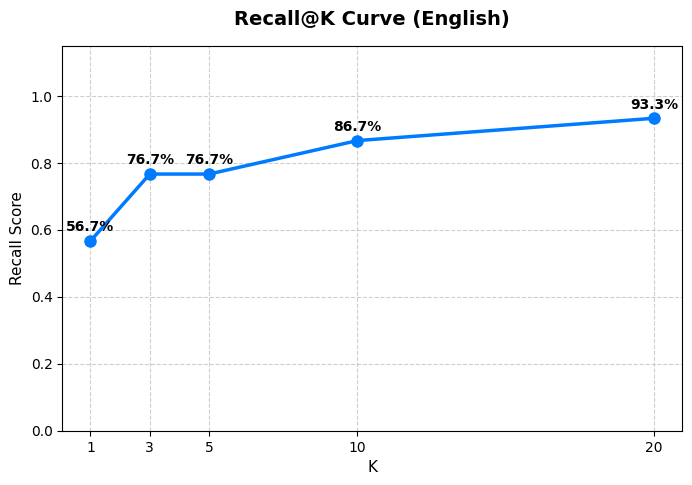

({1: 0.5666666666666667,
  3: 0.7666666666666667,
  5: 0.7666666666666667,
  10: 0.8666666666666667,
  20: 0.9333333333333333},
 np.float64(0.675))

In [49]:
def evaluate_retrieval_system_en():
    k_values = [1, 3, 5, 10, 20]
    recall_hits = {k: 0 for k in k_values}
    reciprocal_ranks = []
    detailed_records = []

    for idx, item in enumerate(queries_en):
        question = item['question']
        gt_id = item['ground_truth']

        retrieved_docs, _ = retrieve_top_k_en(question, k=20)
        retrieved_ids = [doc['id'] for doc in retrieved_docs]

        if gt_id in retrieved_ids:
            rank = retrieved_ids.index(gt_id) + 1
            rr = 1.0 / rank
        else:
            rank = -1
            rr = 0.0

        reciprocal_ranks.append(rr)

        for k in k_values:
            if gt_id in retrieved_ids[:k]:
                recall_hits[k] += 1

        detailed_records.append({
            "No": idx + 1,
            "Question": question,
            "Ground Truth ID": gt_id,
            "Rank": rank if rank != -1 else "N/A",
            "Reciprocal Rank (RR)": f"{rr:.4f}"
        })

    total_queries = len(queries_en)
    recall_scores = {k: recall_hits[k] / total_queries for k in k_values}
    mrr_score = np.mean(reciprocal_ranks)

    summary_table = [
        ["Metric", "Score", "%"],
        ["Recall@1", f"{recall_scores[1]:.4f}", f"{recall_scores[1]*100:.1f}%"],
        ["Recall@3", f"{recall_scores[3]:.4f}", f"{recall_scores[3]*100:.1f}%"],
        ["Recall@5", f"{recall_scores[5]:.4f}", f"{recall_scores[5]*100:.1f}%"],
        ["Recall@10", f"{recall_scores[10]:.4f}", f"{recall_scores[10]*100:.1f}%"],
        ["Recall@20", f"{recall_scores[20]:.4f}", f"{recall_scores[20]*100:.1f}%"],
        ["MRR", f"{mrr_score:.4f}", "-"]
    ]
    print(tabulate(summary_table, headers="firstrow", tablefmt="grid"))

    df_details = pd.DataFrame(detailed_records)
    display(df_details.set_index("No"))

    plt.figure(figsize=(8, 5))
    y_values = [recall_scores[k] for k in k_values]
    plt.plot(k_values, y_values, marker='o', markersize=8, color='#007bff', linestyle='-', linewidth=2.5)

    for k, val in zip(k_values, y_values):
        plt.text(k, val + 0.02, f"{val*100:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.title("Recall@K Curve (English)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("K", fontsize=11)
    plt.ylabel("Recall Score", fontsize=11)
    plt.xticks(k_values)
    plt.ylim(0, 1.15)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    return recall_scores, mrr_score

evaluate_retrieval_system_en()